## Support Ticket Classification and Prioritization

## Loading DataSet-IT Service Ticket Classification Dataset (Kaggle)

In [1]:
import pandas as pd
df=pd.read_csv('all_tickets_processed_improved_v3.csv')

## Printing the dimensions of DataSet(number of rows and features)

In [2]:
df.shape

(47837, 2)

## Displaying first 10 rows of data

In [3]:
df.head(10)

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous
5,mail please dear looks blacklisted receiving m...,Miscellaneous
6,prod servers tunneling prod tunneling va la tu...,Hardware
7,access request dear modules report report cost...,HR Support
8,reset passwords for our client and passwords c...,Access
9,direct reports missing time please action repo...,HR Support


## Displaying last 10 rows of data

In [4]:
df.tail(10)

,Document,Topic_group
47827,bandwidth problems sent thursday july bandwidt...,Hardware
47828,your password expire days sent july re your pa...,Access
47829,sensitive information access sent wednesday ju...,Storage
47830,malfunction sent tuesday july re malfunction h...,Hardware
47831,cannot on outlook account from laptop cannot l...,Administrative rights
47832,git space for a project issues with adding use...,Access
47833,error sent july error hi guys can you help out...,Miscellaneous
47834,connection issues sent tuesday july connection...,Hardware
47835,error cube reports sent tuesday july error hel...,HR Support
47836,running out on extensions hello please be advi...,Hardware


In [5]:
print(df['Topic_group'].value_counts())

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


## visualization of Topic-Group & Ticket Categories

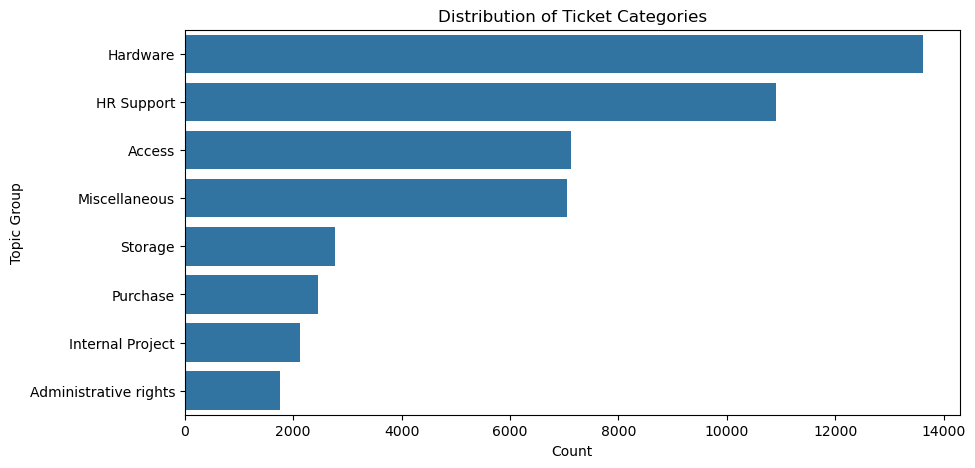

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='Topic_group',
    order=df['Topic_group'].value_counts().index
)

plt.title("Distribution of Ticket Categories")
plt.xlabel("Count")
plt.ylabel("Topic Group")

plt.show()

In [7]:
import nltk
import re
import string

from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saigi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Data Cleaning

In [8]:
stop_words = set(stopwords.words('english'))

In [9]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [10]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [11]:
df['Clean_Document'] = df['Document'].apply(clean_text)

In [12]:
df[['Document','Clean_Document']].head()

,Document,Clean_Document
0,connection with icon icon dear please setup ic...,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,requesting meeting requesting meeting hi pleas...
3,reset passwords for external accounts re expir...,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,mail verification warning hi got attached plea...


## TF-IDF

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(
    df['Clean_Document']
)

y = df['Topic_group']

In [14]:
print(X.shape)

(47837, 5000)


## Splitting the dataset into train(80%) and test(20%) sets

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(38269, 5000)
(9568, 5000)


## Model 1:Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

## Performance Evaluation of Logistic Regression

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)



print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print(classification_report(y_test,y_pred_lr))

Accuracy : 0.8584866220735786
Precision: 0.862607712469191
Recall   : 0.8584866220735786
F1 Score : 0.8584732099375626
                       precision    recall  f1-score   support

               Access       0.92      0.88      0.90      1425
Administrative rights       0.87      0.64      0.74       352
           HR Support       0.87      0.87      0.87      2183
             Hardware       0.80      0.90      0.84      2724
     Internal Project       0.93      0.81      0.86       424
        Miscellaneous       0.84      0.82      0.83      1412
             Purchase       0.97      0.87      0.92       493
              Storage       0.95      0.84      0.89       555

             accuracy                           0.86      9568
            macro avg       0.89      0.83      0.86      9568
         weighted avg       0.86      0.86      0.86      9568



## Confusion Matrix-Logistic regression

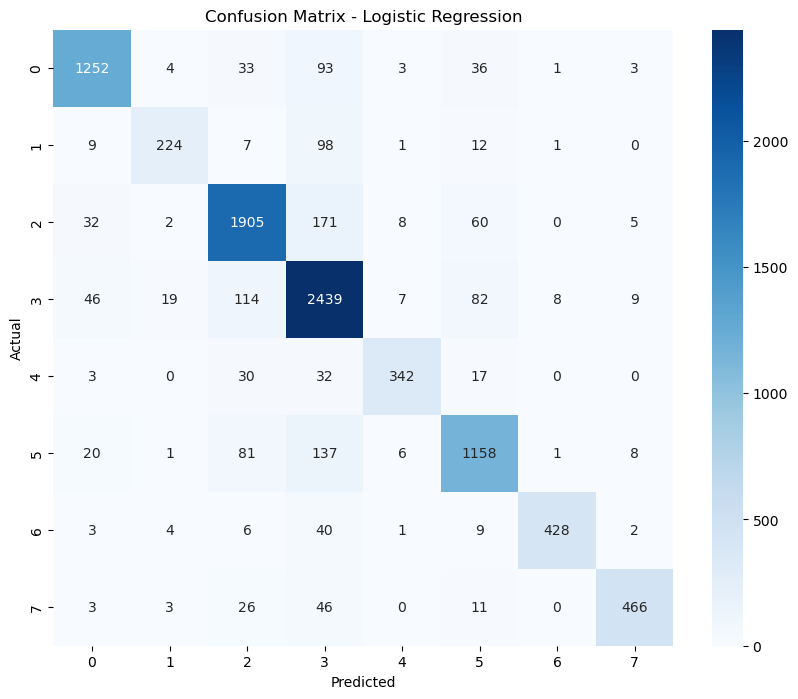

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Model 2: Multinomial Naive Bayes

In [19]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

## Performance Evaluation of Multinomial Naive Bayes

In [20]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)
print(classification_report(y_test,y_pred_nb))

Accuracy : 0.7838628762541806
Precision: 0.8041005528265217
Recall   : 0.7838628762541806
F1 Score : 0.7812888343683184
                       precision    recall  f1-score   support

               Access       0.85      0.79      0.82      1425
Administrative rights       0.93      0.32      0.48       352
           HR Support       0.85      0.77      0.81      2183
             Hardware       0.68      0.90      0.78      2724
     Internal Project       0.91      0.64      0.75       424
        Miscellaneous       0.76      0.74      0.75      1412
             Purchase       0.97      0.84      0.90       493
              Storage       0.92      0.71      0.80       555

             accuracy                           0.78      9568
            macro avg       0.86      0.71      0.76      9568
         weighted avg       0.80      0.78      0.78      9568



## Confusion Matrix of Naive Bayes

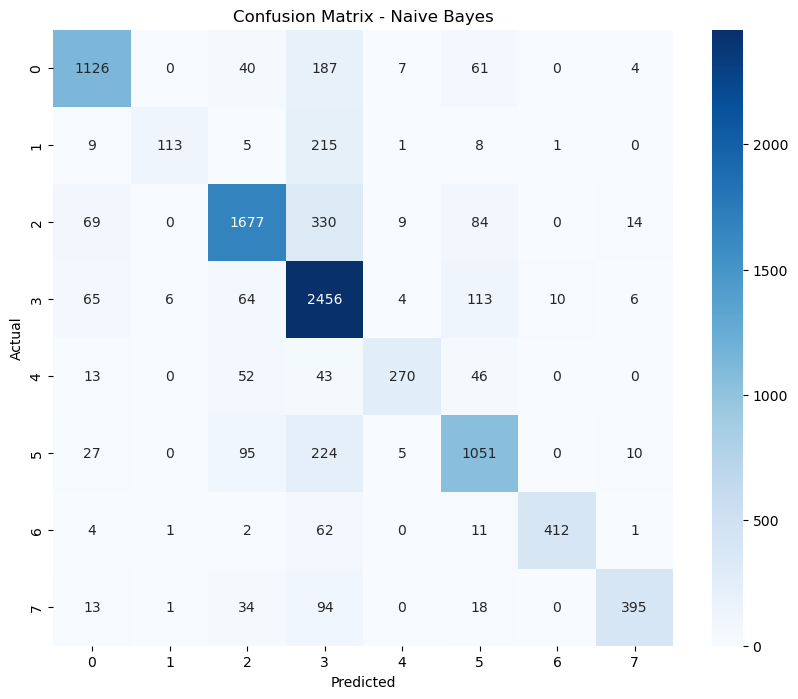

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Model 3: Linear Support Vector Machine

In [22]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

## Performance Evaluation of Support Vector Machine

In [23]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)
print(classification_report(y_test,y_pred_svm))

Accuracy : 0.8575459866220736
Precision: 0.8587292928820538
Recall   : 0.8575459866220736
F1 Score : 0.8575870833071815
                       precision    recall  f1-score   support

               Access       0.90      0.90      0.90      1425
Administrative rights       0.85      0.70      0.77       352
           HR Support       0.86      0.87      0.87      2183
             Hardware       0.82      0.86      0.84      2724
     Internal Project       0.88      0.85      0.86       424
        Miscellaneous       0.83      0.82      0.83      1412
             Purchase       0.96      0.88      0.92       493
              Storage       0.92      0.88      0.90       555

             accuracy                           0.86      9568
            macro avg       0.88      0.85      0.86      9568
         weighted avg       0.86      0.86      0.86      9568



## Confusion Matrix of Linear Support Vector Machine

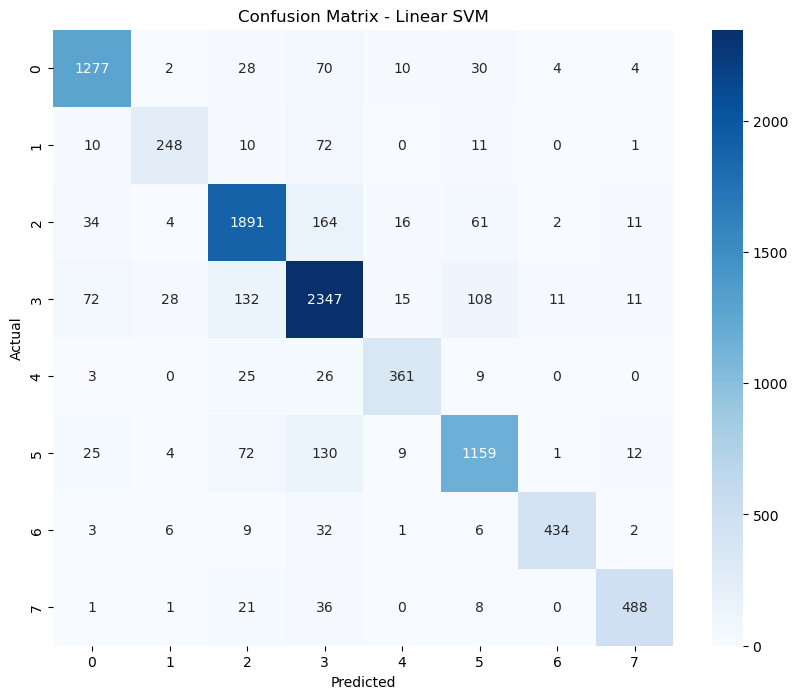

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Linear SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Comparison of Models

In [25]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],

    "Accuracy":[
        lr_accuracy,
        nb_accuracy,
        svm_accuracy
    ],

    "Precision":[
        lr_precision,
        nb_precision,
        svm_precision
    ],

    "Recall":[
        lr_recall,
        nb_recall,
        svm_recall
    ],

    "F1 Score":[
        lr_f1,
        nb_f1,
        svm_f1
    ]

})

# Sort by accuracy and save back
results = results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.858487,0.862608,0.858487,0.858473
1,Linear SVM,0.857546,0.858729,0.857546,0.857587
2,Naive Bayes,0.783863,0.804101,0.783863,0.781289


## Comparison of 'Accuracy' among Logistic Regression, Naive Bayes, Linear SVM

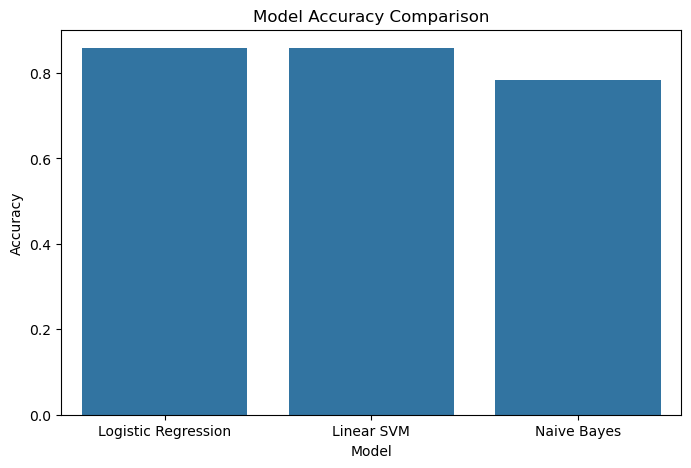

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

In [27]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.858487,0.862608,0.858487,0.858473
1,Linear SVM,0.857546,0.858729,0.857546,0.857587
2,Naive Bayes,0.783863,0.804101,0.783863,0.781289


## Comparison of 'F1-SCORE' among Logistic Regression, Naive Bayes, Linear SVM

In [28]:
import numpy as np
feature_names = tfidf.get_feature_names_out()

for i, category in enumerate(lr.classes_):
    top10 = np.argsort(lr.coef_[i])[-10:]
    print(f"\nTop words for {category}:")
    print([feature_names[j] for j in top10])


Top words for Access:
['users', 'accounts', 'git', 'repository', 'password', 'license', 'card', 'user', 'account', 'confluence']

Top words for Administrative rights:
['calendar', 'version', 'update', 'exchange', 'software', 'windows', 'install', 'issues', 'upgrade', 'outlook']

Top words for HR Support:
['hours', 'timecard', 'submit', 'leaver', 'access', 'leave', 'error', 'time', 'starter', 'oracle']

Top words for Hardware:
['backpack', 'call', 'cable', 'ram', 'meeting', 'connection', 'phone', 'room', 'monitor', 'laptop']

Top words for Internal Project:
['opportunity', 'unknown', 'pipelines', 'import', 'pas', 'setup', 'pipeline', 'codes', 'project', 'code']

Top words for Miscellaneous:
['owner', 'approved', 'name', 'tickets', 'add', 'ticket', 'groups', 'approve', 'change', 'approval']

Top words for Purchase:
['receipt', 'devices', 'items', 'allocation', 'log', 'device', 'administrator', 'installation', 'po', 'purchase']

Top words for Storage:
['size', 'increase', 'permissions', 

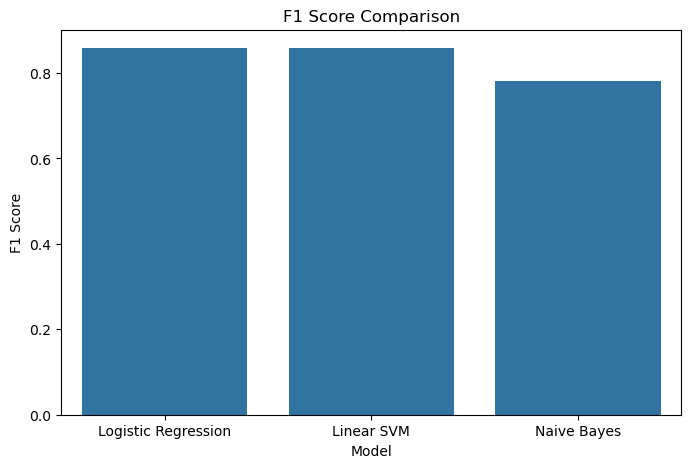

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='F1 Score'
)

plt.title('F1 Score Comparison')
plt.show()

## Comparison of 'Precision' among Logistic Regression, Naive Bayes, Linear SVM

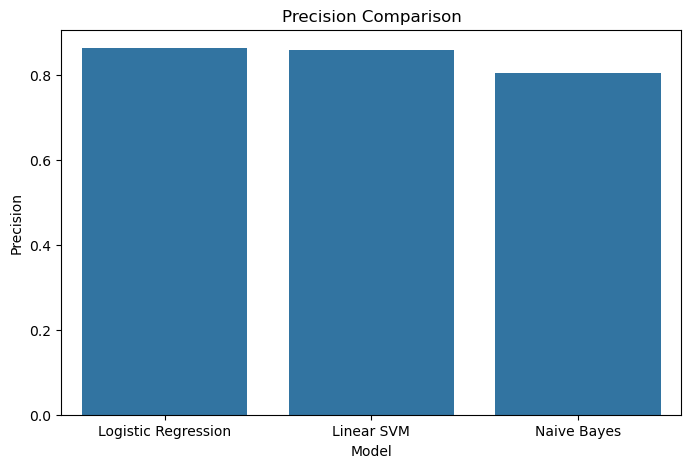

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Precision'
)

plt.title('Precision Comparison')
plt.show()

## Comparison of 'Recall' among Logistic Regression, Naive Bayes, Linear SVM

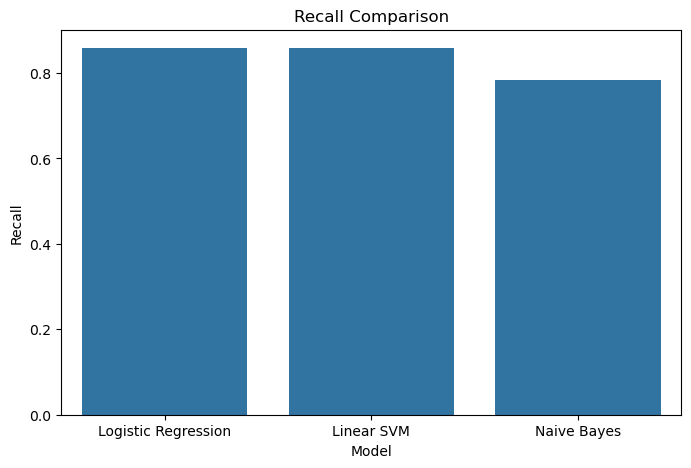

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Recall'
)

plt.title('Recall Comparison')
plt.show()

## Priority Prediction (High / Medium / Low)

The task requires not just classifying tickets by **category**, but also assigning a **priority level** (High / Medium / Low) to each ticket so support teams know which to resolve first.

Priority is assigned using a rule-based approach derived from ticket category and urgency keywords:


In [32]:
HIGH_PRIORITY_CATEGORIES = {'Administrative rights', 'Storage'}
MEDIUM_PRIORITY_CATEGORIES = {'Hardware', 'Access', 'Internal Project', 'Purchase'}
URGENT_KEYWORDS = ['urgent', 'cannot access', 'broken', 'down', 'not working',
                   'critical', 'emergency', 'immediately', 'asap']

def assign_priority(predicted_category, ticket_text):
    text_lower = str(ticket_text).lower()
    has_urgent = any(kw in text_lower for kw in URGENT_KEYWORDS)
    if has_urgent or predicted_category in HIGH_PRIORITY_CATEGORIES:
        return 'High'
    elif predicted_category in MEDIUM_PRIORITY_CATEGORIES:
        return 'Medium'
    else:
        return 'Low'

# Use .loc (label-based) not .iloc (position-based) to correctly fetch rows by index
test_docs = df.loc[y_test.index, 'Document'].values
priority_labels = [
    assign_priority(pred, doc)
    for pred, doc in zip(y_pred_lr, test_docs)
]

priority_series = pd.Series(priority_labels, name='Priority')
print('Priority Distribution on Test Set:')
print(priority_series.value_counts())


Priority Distribution on Test Set:
Priority
Medium    4527
Low       3287
High      1754
Name: count, dtype: int64


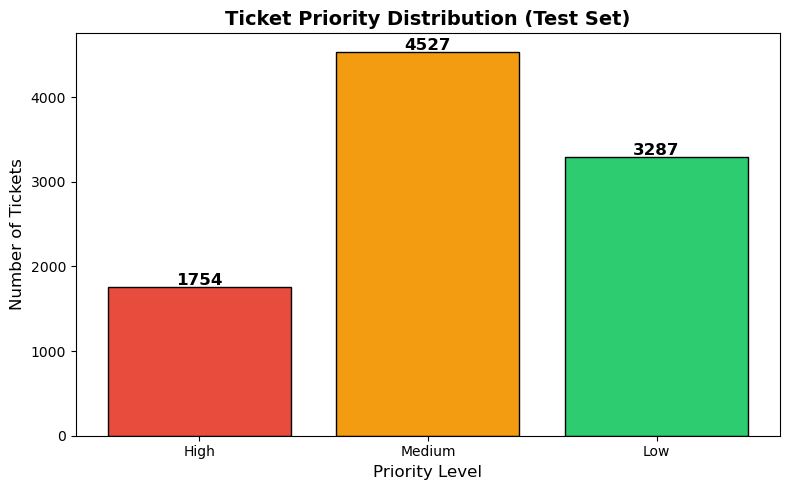


Sample Classified Tickets with Priority:
                                                                                                                                                                                           Document Predicted_Category Priority
12352                                                                          project codes july pm codes hello please assign task thank kind regards july pm codes hi pm attached codes pm thanks   Internal Project   Medium
33948  new starter pop ad july re date merci ale ext ale street center july re date hello please find attached filled thanks friday pm date hello please fill enclosed thanks ext ale street center         HR Support      Low
21267                                                                                add to thursday february re update thanks please add blacklist manage kind regards thursday february re update      Miscellaneous      Low
17680                                                         

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

priority_counts = priority_series.value_counts().reindex(['High','Medium','Low'])

colors = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure(figsize=(8,5))
bars = plt.bar(priority_counts.index, priority_counts.values, color=colors, edgecolor='black')

for bar, val in zip(bars, priority_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha='center', fontweight='bold', fontsize=12)

plt.title('Ticket Priority Distribution (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Priority Level', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.tight_layout()
plt.show()

print('\nSample Classified Tickets with Priority:')
sample_idx = y_test.index[:5]
sample_docs = df.loc[sample_idx, ['Document']].copy()
sample_docs['Predicted_Category'] = list(y_pred_lr[:5])
sample_docs['Priority'] = list(priority_labels[:5])
print(sample_docs[['Document','Predicted_Category','Priority']].to_string())

## Business Insights

- Logistic Regression achieved the highest accuracy of 85.85%.
- The model can automatically route support tickets to the correct department.
- Automated ticket classification reduces manual effort and response time.
- HR Support and Hardware categories were the most common ticket types.
- The system can help organizations manage large ticket volumes efficiently.

## Conclusion

A machine learning-based ticket classification system was developed using NLP techniques.

The text data was cleaned and transformed using TF-IDF vectorization.

Three machine learning models were trained and evaluated:
- Logistic Regression
- Multinomial Naive Bayes
- Linear SVM

Among them, Logistic Regression achieved the best performance with an accuracy of 85.85%.

The developed system can automatically classify incoming support tickets into their respective categories, helping organizations improve support efficiency and reduce manual workload.